# 02 - Feature Engineering

This notebook demonstrates the statistical feature extraction capabilities.

Note: For this project, we feed raw windows directly to the transformer, so explicit feature engineering is optional. This notebook shows the available features for reference and potential hybrid approaches.

In [1]:
import sys

sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np

from threatsim.data import create_windows, load_nab_data, nab_anomaly_mask
from threatsim.features import extract_features, get_feature_names

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# Load data and create windows
df, anomaly_timestamps = load_nab_data(
    "realKnownCause/machine_temperature_system_failure.csv"
)
anomaly_mask = nab_anomaly_mask(df, anomaly_timestamps)
values = df["value"].values.astype(np.float32)
windows, labels = create_windows(values, anomaly_mask, window_size=50, step_size=10)

print(f"Windows shape: {windows.shape}")

Windows shape: (2265, 50)


In [3]:
# Extract features
features = extract_features(windows)
feature_names = get_feature_names()

print(f"Features shape: {features.shape}")
print(f"Feature names: {feature_names}")

Features shape: (2265, 10)
Feature names: ['mean', 'std', 'min', 'max', 'range', 'slope', 'skewness', 'kurtosis', 'zero_crossings', 'autocorr_1']


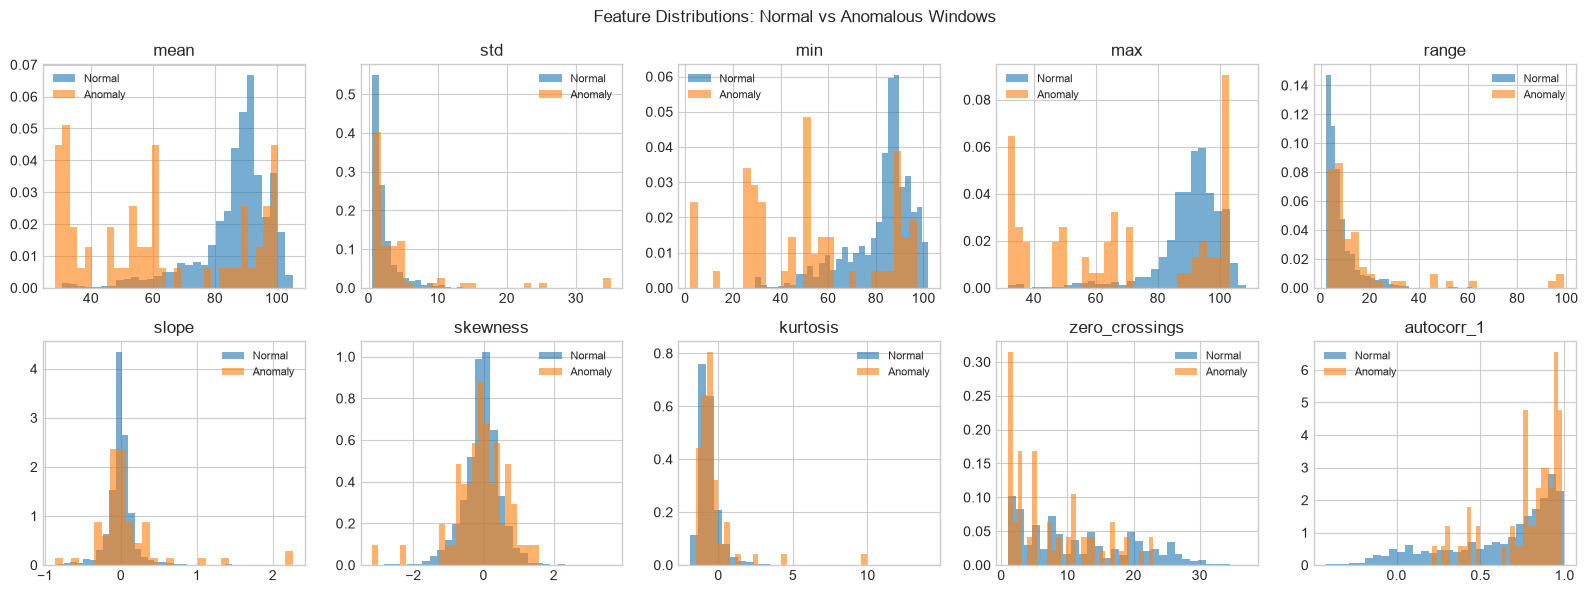

In [4]:
# Compare feature distributions: normal vs anomalous
normal_mask = labels == 0
anomaly_idx = labels == 1

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()

for i, (ax, name) in enumerate(zip(axes, feature_names)):
    ax.hist(features[normal_mask, i], bins=30, alpha=0.6, label="Normal", density=True)
    ax.hist(features[anomaly_idx, i], bins=30, alpha=0.6, label="Anomaly", density=True)
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.suptitle("Feature Distributions: Normal vs Anomalous Windows")
plt.tight_layout()
plt.show()

## Summary

The extracted features show different distributions between normal and anomalous windows. Features like `std`, `range`, and `slope` may help distinguish anomalies.

For this project, we use the transformer directly on raw sequences, which learns its own representations. These explicit features could be concatenated for a hybrid approach.